## Exploratory Data Analysis
The process of examining and visualising a dataset to understand its main characteristics, detect patterns, spot anomalies, and test assumptions, often using summary statistics and graphs. It helps you get insights into the data before applying formal modeling or machine learning.

Understand the raw data:
- Distribution plots
- Correlations
- Class imbalance
- Outliers
- Feature ranges
- Identify skew
- Domain anomalies
- Leakage detection
- Decide which features matter

Here we will be using pandas to handle storing and processing the data

In [57]:
import pandas as pd

In [58]:
df = pd.read_csv("data/nba_games.csv",index_col=0)  #pulling the csv file from our parsed csv dataset

In [59]:
df.head()

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,...,tov%_max_opp,usg%_max_opp,ortg_max_opp,drtg_max_opp,team_opp,total_opp,home_opp,season,date,won
2630,240.0,39.0,75.0,0.520,13.0,19.0,0.684,22.0,22.0,1.000,...,50.0,29.7,150.0,133.0,UTA,104,0,2017,2016-10-25,True
2631,240.0,40.0,82.0,0.488,8.0,24.0,0.333,16.0,16.0,1.000,...,50.0,39.2,220.0,120.0,POR,113,1,2017,2016-10-25,False
2632,240.0,40.0,85.0,0.471,7.0,33.0,0.212,13.0,18.0,0.722,...,100.0,36.2,263.0,112.0,SAS,129,0,2017,2016-10-25,False
2633,240.0,47.0,98.0,0.480,12.0,24.0,0.500,23.0,26.0,0.885,...,75.0,31.8,139.0,143.0,GSW,100,1,2017,2016-10-25,True
2634,240.0,45.0,94.0,0.479,13.0,35.0,0.371,14.0,19.0,0.737,...,50.0,36.8,153.0,125.0,NYK,88,0,2017,2016-10-25,True


In [60]:
for column in df.columns:
    print(column)

mp
fg
fga
fg%
3p
3pa
3p%
ft
fta
ft%
orb
drb
trb
ast
stl
blk
tov
pf
pts
ts%
efg%
3par
ftr
orb%
drb%
trb%
ast%
stl%
blk%
tov%
usg%
ortg
drtg
fg_max
fga_max
fg%_max
3p_max
3pa_max
3p%_max
ft_max
fta_max
ft%_max
orb_max
drb_max
trb_max
ast_max
stl_max
blk_max
tov_max
pf_max
pts_max
gmsc_max
+/-_max
ts%_max
efg%_max
3par_max
ftr_max
orb%_max
drb%_max
trb%_max
ast%_max
stl%_max
blk%_max
tov%_max
usg%_max
ortg_max
drtg_max
team
total
home
mp_opp
fg_opp
fga_opp
fg%_opp
3p_opp
3pa_opp
3p%_opp
ft_opp
fta_opp
ft%_opp
orb_opp
drb_opp
trb_opp
ast_opp
stl_opp
blk_opp
tov_opp
pf_opp
pts_opp
ts%_opp
efg%_opp
3par_opp
ftr_opp
orb%_opp
drb%_opp
trb%_opp
ast%_opp
stl%_opp
blk%_opp
tov%_opp
usg%_opp
ortg_opp
drtg_opp
fg_max_opp
fga_max_opp
fg%_max_opp
3p_max_opp
3pa_max_opp
3p%_max_opp
ft_max_opp
fta_max_opp
ft%_max_opp
orb_max_opp
drb_max_opp
trb_max_opp
ast_max_opp
stl_max_opp
blk_max_opp
tov_max_opp
pf_max_opp
pts_max_opp
gmsc_max_opp
+/-_max_opp
ts%_max_opp
efg%_max_opp
3par_max_opp
ftr_max_opp
orb%_m

In [61]:
df['3p%'].describe()

count    7848.000000
mean        0.357160
std         0.090438
min         0.053000
25%         0.296000
50%         0.355000
75%         0.417000
max         0.842000
Name: 3p%, dtype: float64

In [62]:
removed_columns = ["mp","team","team_opp","total","total_opp","home","home_opp","season","date","won"]
selected_columns = df.columns[~df.columns.isin(removed_columns)]

- multiple histograms on one figure to compare histograms easier and find which has most important trend
- curve following the trend
- take maximum and minimum values for each column to find bin sizes and ranges
- no label for bins to improve clarity and space
- display the x axis label for each histogram
- display title as win%
- display min, max, std, mean for each histogram

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def win_histogram_with_trend(x_axis, ax, bar_width=0.3, gap=0.05, show_stats=True):
    """
    Plots empirical win% histogram with a smooth polynomial trend line.
    """
    col_values = df[x_axis]

    # Column statistics
    col_min = col_values.min()
    col_max = col_values.max()
    col_mean = col_values.mean()
    col_std = col_values.std()
    stats_text = f"min={col_min:.2f}, max={col_max:.2f}, mean={col_mean:.2f}, std={col_std:.2f}" if show_stats else ''

    # Define bins
    if col_min == col_max:
        bins = [col_min - 0.5, col_max + 0.5]
    else:
        bins = np.linspace(col_min, col_max, 11)  # 10 bins

    x_bins = pd.cut(col_values, bins=bins, include_lowest=True)

    # Compute empirical win% per bin
    win_rate_by_bin = df.groupby(x_bins)['won'].mean().reindex(x_bins.cat.categories).fillna(0)

    # X positions for bars
    indices = np.arange(len(win_rate_by_bin))
    positions = indices * (bar_width + gap)

    # Plot bars
    ax.bar(
        positions,
        win_rate_by_bin.values,
        width=bar_width,
        color='royalblue',
        edgecolor='black',
        alpha=0.7,
        label='Empirical Win %'
    )

    # Polynomial trend line (2nd-degree)
    if len(win_rate_by_bin) > 2:
        coeffs = np.polyfit(positions, win_rate_by_bin.values, deg=2)
        poly = np.poly1d(coeffs)
        x_smooth = np.linspace(positions.min(), positions.max(), 300)
        y_smooth = poly(x_smooth)

        # Optional: clip to 0–1 for percentages
        y_smooth = np.clip(y_smooth, 0, 1)

        ax.plot(x_smooth, y_smooth, color='red', linewidth=2, label='Trend Curve')
        ax.fill_between(x_smooth, y_smooth, color='red', alpha=0.2)

    # Labels, grid, title
    ax.set_xticks([])
    ax.set_title(f'{x_axis}\n{stats_text}', fontsize=9)
    ax.set_ylabel('Win %', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=7)


In [97]:
def histogram_grid(cols_to_plot):
    #given a list of columns to analyse against win percentage
    #generate a grid of histograms
    n_cols = 3  # number of plots per row
    n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))

    axes = axes.flatten()  # flatten in case n_rows > 1

    for ax, col in zip(axes, cols_to_plot):
        win_histogram_with_trend(col, ax)

    # If there are unused axes, remove them
    for ax in axes[len(cols_to_plot):]:
        ax.remove()

    plt.tight_layout()
    plt.show()

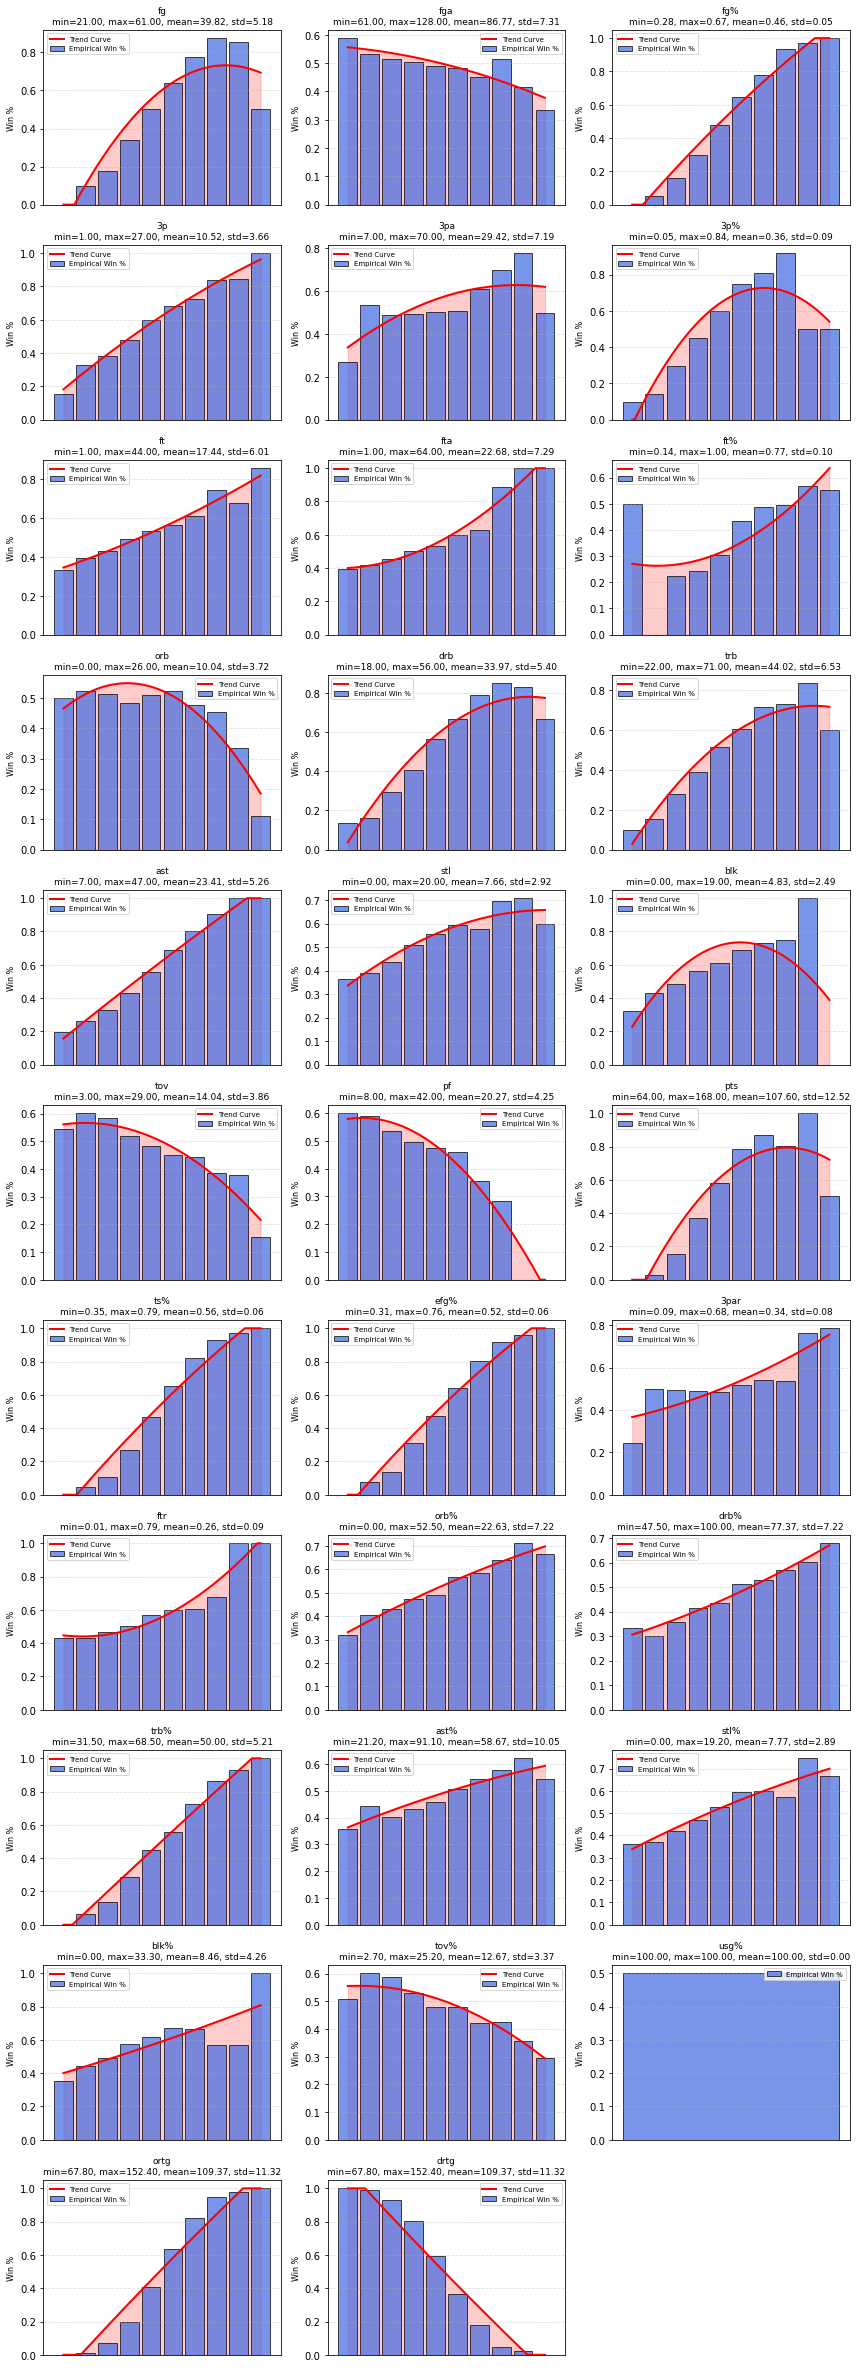

In [98]:
team_cols = [c for c in selected_columns if not "_opp" in c and not "_max" in c]
histogram_grid(team_cols)

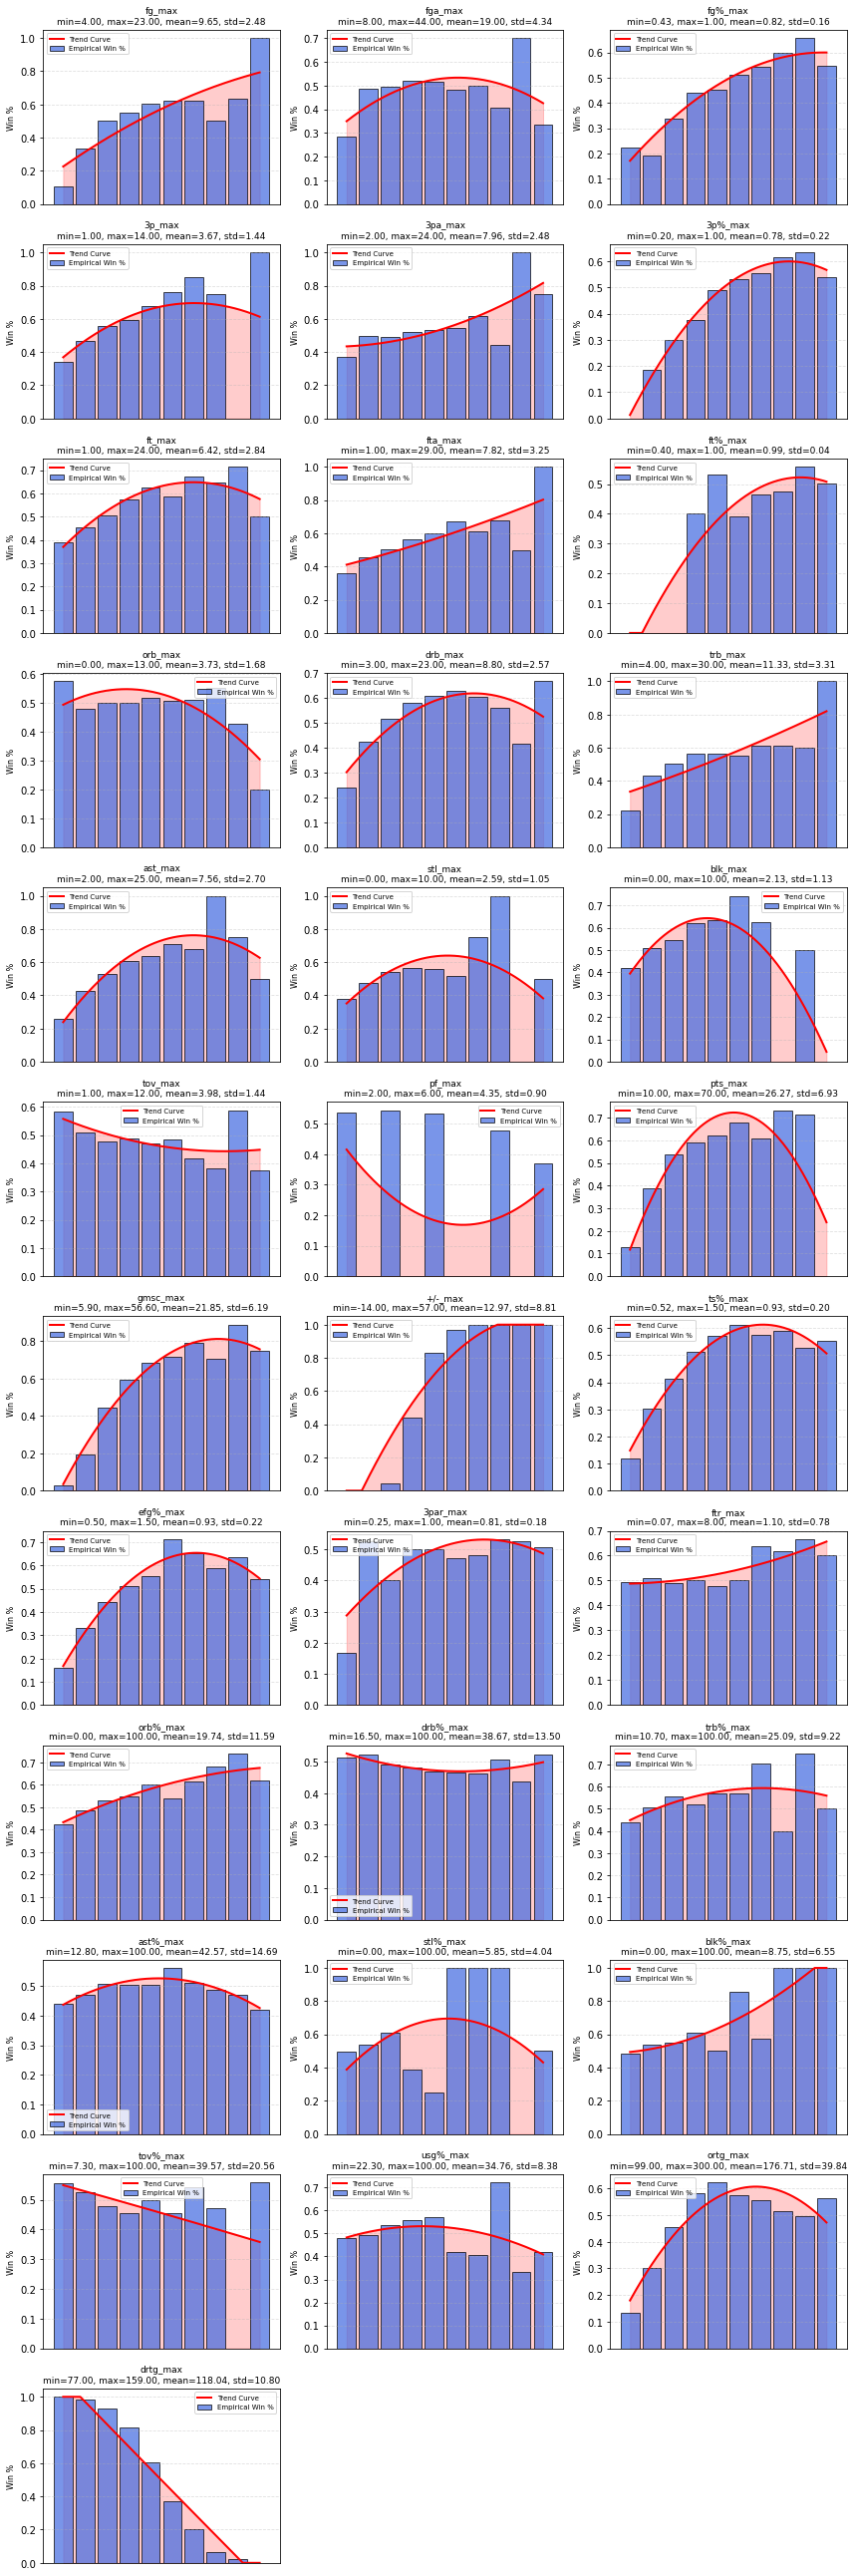

In [99]:
max_cols = [c for c in selected_columns if not "_opp" in c and "_max" in c]
histogram_grid(max_cols)

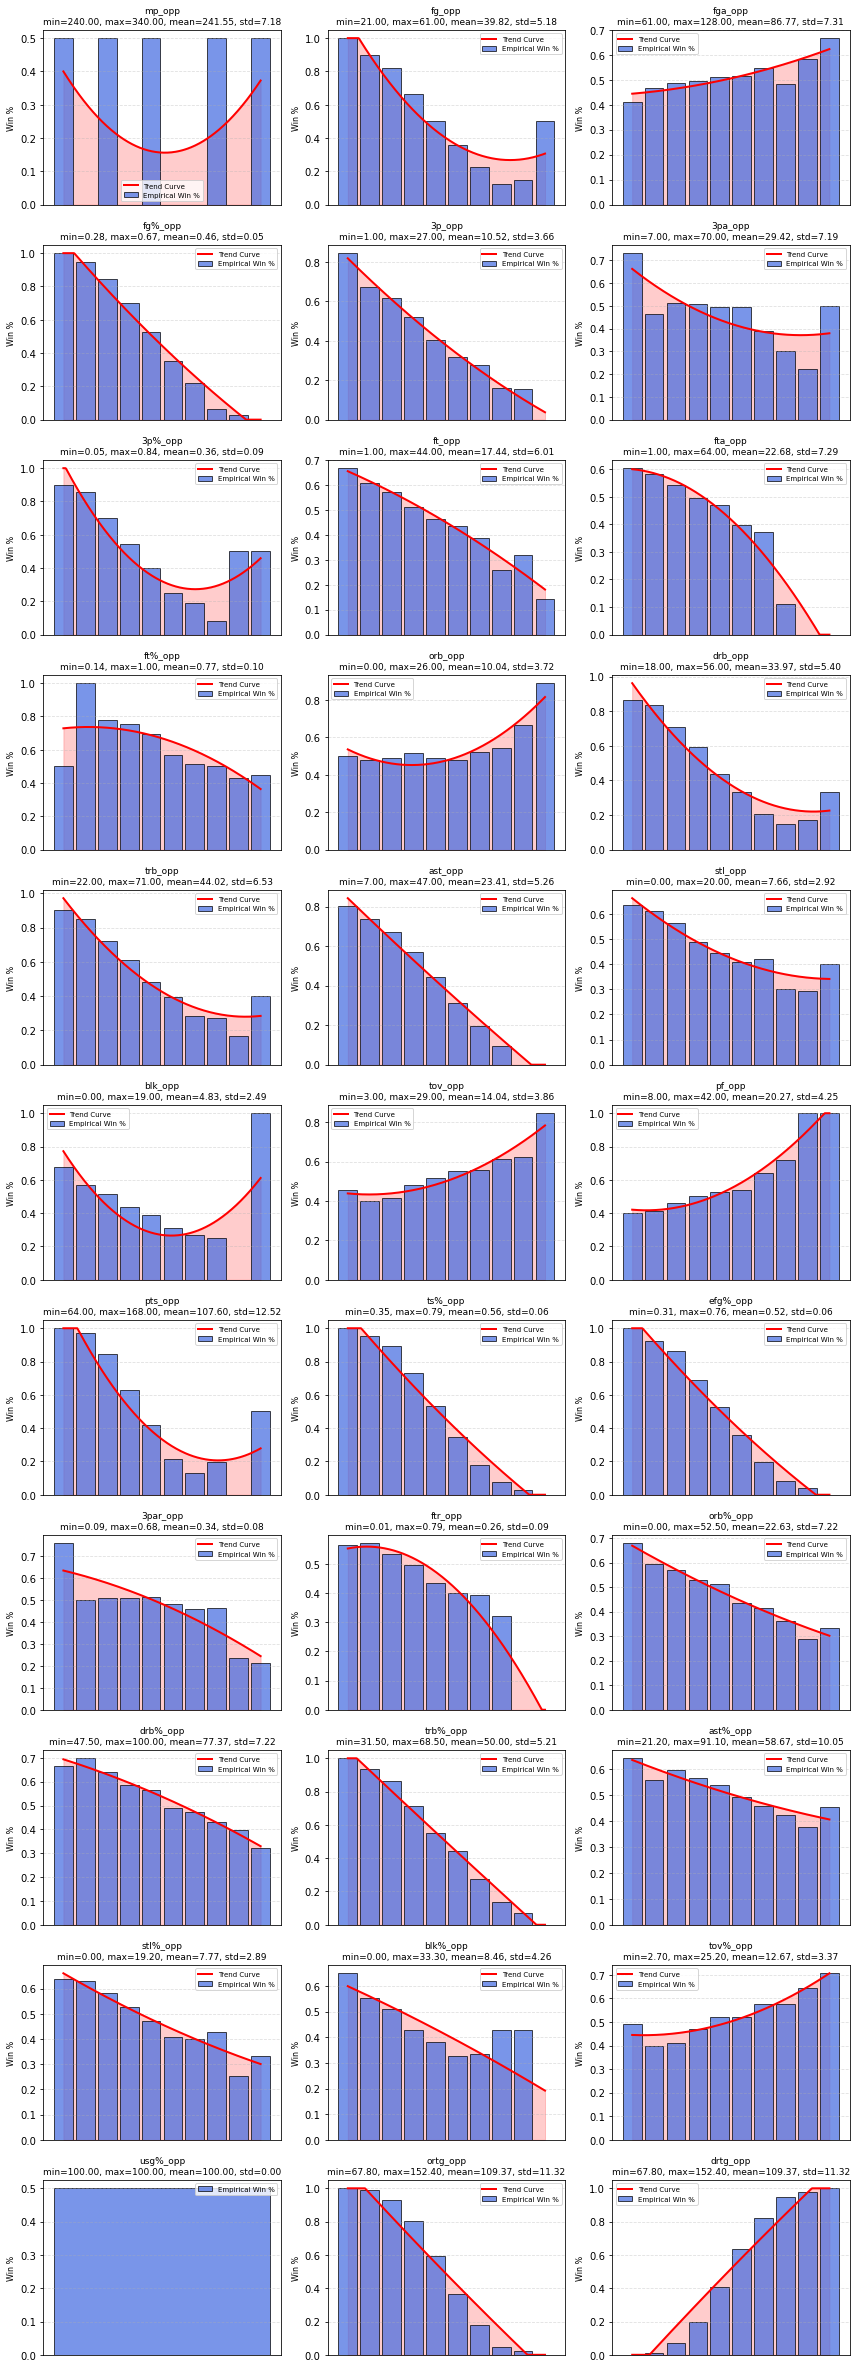

In [100]:
opp_team_cols = [c for c in selected_columns if "_opp" in c and not "_max" in c]
histogram_grid(opp_team_cols)

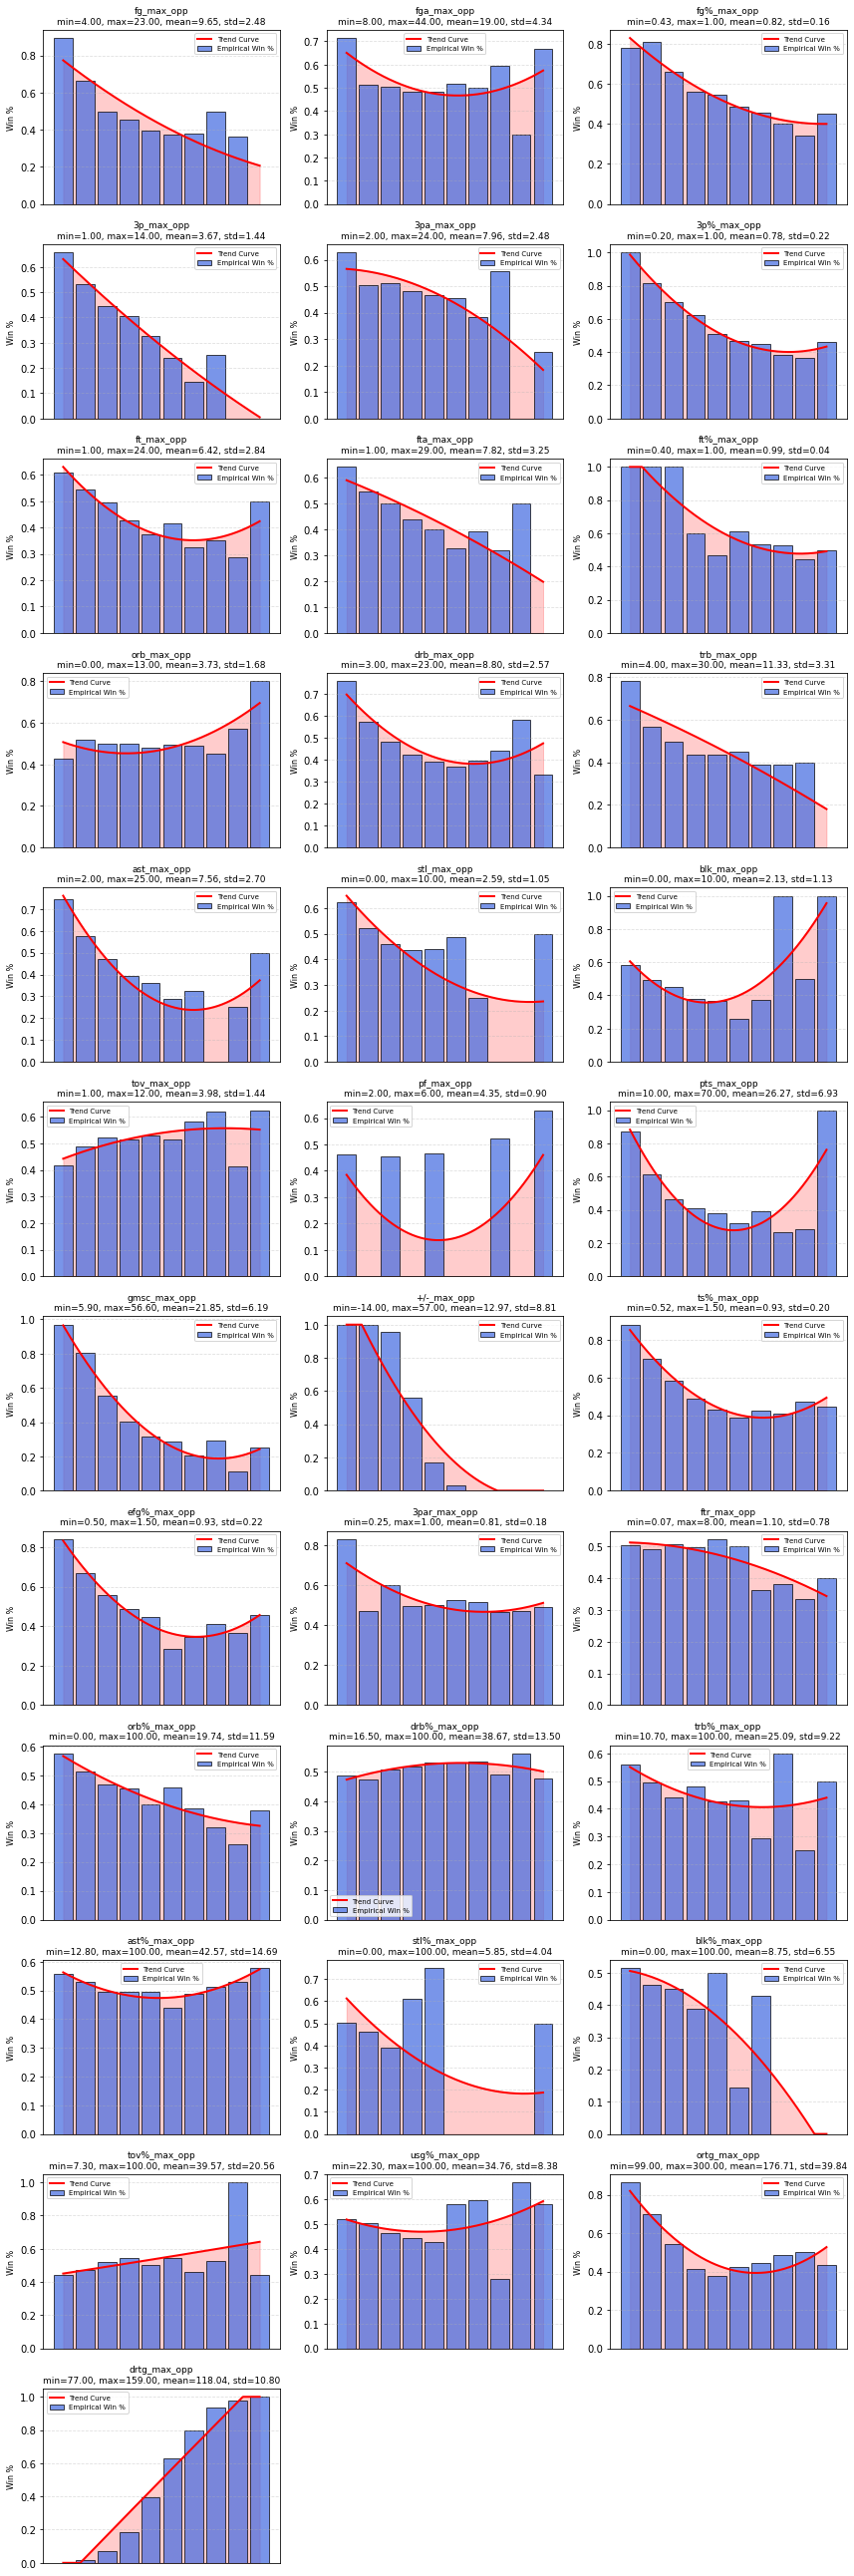

In [101]:
opp_team_max_cols = [c for c in selected_columns if "_opp" in c and "_max" in c]
histogram_grid(opp_team_max_cols)

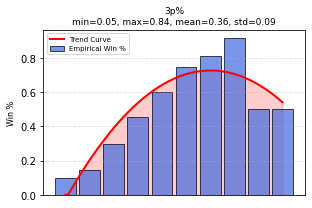

In [103]:
histogram_grid(["3p%"])

## Potential Relationships
There are some potential relationships worth looking into and testing, that could yield meaningful trends. Some possible one's that stick out to me the most are:
- Home vs Away
- Win percentage based on performance at home from past x games
- Average performance from the past x games
- Number of days rested between the last game
- Performance against the opponent last x games in same season or including past seasons
- Playoffs vs Season game
- Overtime games affecting stats

### Home vs Away
Splits the dataframe into two groups, home and away. Then on each group it applies a function which returns the number of games won in that group / the number of games in that group (win percentage)

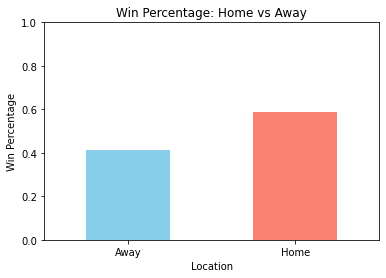

In [104]:
import matplotlib.pyplot as plt

# Calculate win percentages for home vs away
win_pct = df.groupby("home").apply(lambda x: x[x["won"] == 1].shape[0] / x.shape[0])

# Plot bar chart
plt.figure(figsize=(6,4))
win_pct.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Win Percentage: Home vs Away")
plt.xlabel("Location")
plt.ylabel("Win Percentage")
plt.xticks(ticks=[0,1], labels=['Away', 'Home'], rotation=0)
plt.ylim(0,1)
plt.show()

As we can see, teams often perform better at home than away. We can include a ‘home/away’ feature in the model to account for this when making predictions.

### Average performance from the past x games
To find if a team has been on a hot streak, we can look at the rolling average from the previous x games.

In [105]:
removed_columns = ["season", "date", "won", "team", "team_opp"]
selected_columns = df.columns[~df.columns.isin(removed_columns)]

In [106]:
def find_team_averages(team):
    #rolling = team.rolling(10).mean()
    rolling = team.shift().rolling(10, min_periods=1).mean()
    return rolling

df_rolling = df[list(selected_columns) + ["won", "team", "season"]]
df_rolling = df_rolling.groupby(["team", "season"], group_keys=False).apply(find_team_averages)

Adding all rolling columns to the original dataframe with a new label.

In [107]:
rolling_cols = [f"{col}_10" for col in df_rolling.columns]
df_rolling.columns = rolling_cols

In [108]:
df_rolling["won_10"]

2630     NaN
2631     NaN
2632     NaN
2633     NaN
2634     NaN
        ... 
10473    0.7
10474    0.7
10475    0.7
10476    0.7
10477    0.7
Name: won_10, Length: 7848, dtype: float64

In [109]:
df_rolling = pd.concat([df, df_rolling], axis=1)

In [110]:
df_rolling = df_rolling.dropna() #Drop all null/na values

In [111]:
for column in df_rolling.columns:
    print(column)

mp
fg
fga
fg%
3p
3pa
3p%
ft
fta
ft%
orb
drb
trb
ast
stl
blk
tov
pf
pts
ts%
efg%
3par
ftr
orb%
drb%
trb%
ast%
stl%
blk%
tov%
usg%
ortg
drtg
fg_max
fga_max
fg%_max
3p_max
3pa_max
3p%_max
ft_max
fta_max
ft%_max
orb_max
drb_max
trb_max
ast_max
stl_max
blk_max
tov_max
pf_max
pts_max
gmsc_max
+/-_max
ts%_max
efg%_max
3par_max
ftr_max
orb%_max
drb%_max
trb%_max
ast%_max
stl%_max
blk%_max
tov%_max
usg%_max
ortg_max
drtg_max
team
total
home
mp_opp
fg_opp
fga_opp
fg%_opp
3p_opp
3pa_opp
3p%_opp
ft_opp
fta_opp
ft%_opp
orb_opp
drb_opp
trb_opp
ast_opp
stl_opp
blk_opp
tov_opp
pf_opp
pts_opp
ts%_opp
efg%_opp
3par_opp
ftr_opp
orb%_opp
drb%_opp
trb%_opp
ast%_opp
stl%_opp
blk%_opp
tov%_opp
usg%_opp
ortg_opp
drtg_opp
fg_max_opp
fga_max_opp
fg%_max_opp
3p_max_opp
3pa_max_opp
3p%_max_opp
ft_max_opp
fta_max_opp
ft%_max_opp
orb_max_opp
drb_max_opp
trb_max_opp
ast_max_opp
stl_max_opp
blk_max_opp
tov_max_opp
pf_max_opp
pts_max_opp
gmsc_max_opp
+/-_max_opp
ts%_max_opp
efg%_max_opp
3par_max_opp
ftr_max_opp
orb%_m

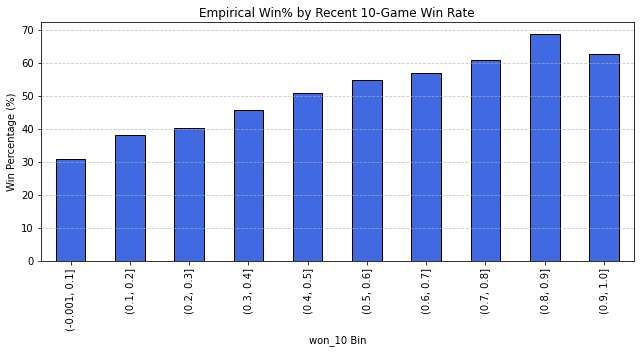

In [112]:
import numpy as np

bins = np.arange(0, 1.1, 0.1)
won_10_bins = pd.cut(df_rolling['won_10'], bins=bins, include_lowest=True)
win_rate_by_bin = df_rolling.groupby(won_10_bins)['won'].mean() * 100

win_rate_by_bin.plot(kind='bar', color='royalblue', edgecolor='black', figsize=(9,5))
plt.title('Empirical Win% by Recent 10-Game Win Rate')
plt.ylabel('Win Percentage (%)')
plt.xlabel('won_10 Bin')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Number of days rested between the last game
- New column for number of days since last game
- What is the least/most number of days between two season games?
- Find the right bin sizes and quantity for analysis based on range
- Group by bins and the win percentage for each bin

Finding out details about the next match for each team, who's at home, who are they playing, and what date the match is.

In [19]:
df_rested = df

In [15]:
def shift_col(team, col_name):
    next_col = team[col_name].shift(-1)
    return next_col

def add_col(df, col_name):
    return df.groupby("team", group_keys=False).apply(lambda x: shift_col(x, col_name))

df_rested["home_next"] = add_col(df_rested, "home")
df_rested["team_opp_next"] = add_col(df_rested, "team_opp")
df_rested["date_next"] = add_col(df_rested, "date")

df_rested = df_rested.copy()

In [17]:
full = df_rested.merge(
    df_rested[["team_opp_next", "date_next", "team"]], 
    left_on=["team", "date_next"], 
    right_on=["team_opp_next", "date_next"]
)

In [18]:
full[["team_x", "team_opp_next_x", "team_y", "team_opp_next_y", "date_next"]]

,team_x,team_opp_next_x,team_y,team_opp_next_y,date_next
0,UTA,LAL,LAL,UTA,2016-10-28
1,GSW,NOP,NOP,GSW,2016-10-28
2,SAS,SAC,SAC,SAS,2016-10-27
3,CLE,TOR,TOR,CLE,2016-10-28
4,NYK,MEM,MEM,NYK,2016-10-29
...,...,...,...,...,...
7811,GSW,TOR,TOR,GSW,2019-06-07
7812,TOR,GSW,GSW,TOR,2019-06-10
7813,GSW,TOR,TOR,GSW,2019-06-10
7814,GSW,TOR,TOR,GSW,2019-06-13


In [19]:
for column in full.columns:
    print(column)

mp
fg
fga
fg%
3p
3pa
3p%
ft
fta
ft%
orb
drb
trb
ast
stl
blk
tov
pf
pts
ts%
efg%
3par
ftr
orb%
drb%
trb%
ast%
stl%
blk%
tov%
usg%
ortg
drtg
fg_max
fga_max
fg%_max
3p_max
3pa_max
3p%_max
ft_max
fta_max
ft%_max
orb_max
drb_max
trb_max
ast_max
stl_max
blk_max
tov_max
pf_max
pts_max
gmsc_max
+/-_max
ts%_max
efg%_max
3par_max
ftr_max
orb%_max
drb%_max
trb%_max
ast%_max
stl%_max
blk%_max
tov%_max
usg%_max
ortg_max
drtg_max
team_x
total
home
mp_opp
fg_opp
fga_opp
fg%_opp
3p_opp
3pa_opp
3p%_opp
ft_opp
fta_opp
ft%_opp
orb_opp
drb_opp
trb_opp
ast_opp
stl_opp
blk_opp
tov_opp
pf_opp
pts_opp
ts%_opp
efg%_opp
3par_opp
ftr_opp
orb%_opp
drb%_opp
trb%_opp
ast%_opp
stl%_opp
blk%_opp
tov%_opp
usg%_opp
ortg_opp
drtg_opp
fg_max_opp
fga_max_opp
fg%_max_opp
3p_max_opp
3pa_max_opp
3p%_max_opp
ft_max_opp
fta_max_opp
ft%_max_opp
orb_max_opp
drb_max_opp
trb_max_opp
ast_max_opp
stl_max_opp
blk_max_opp
tov_max_opp
pf_max_opp
pts_max_opp
gmsc_max_opp
+/-_max_opp
ts%_max_opp
efg%_max_opp
3par_max_opp
ftr_max_opp
orb%

In [21]:
full["date"] = pd.to_datetime(full["date"])
full["date_next"] = pd.to_datetime(full["date_next"])

In [22]:
full["days_rested"] = (full["date_next"] - full["date"]).dt.days

In [23]:
full = full[full["days_rested"] <= 4]

In [24]:
full["days_rested"].value_counts()

2    4701
3    1330
1    1318
4     264
Name: days_rested, dtype: int64

In [25]:
full["days_rested"].describe()

count    7613.000000
mean        2.070931
std         0.693951
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         4.000000
Name: days_rested, dtype: float64

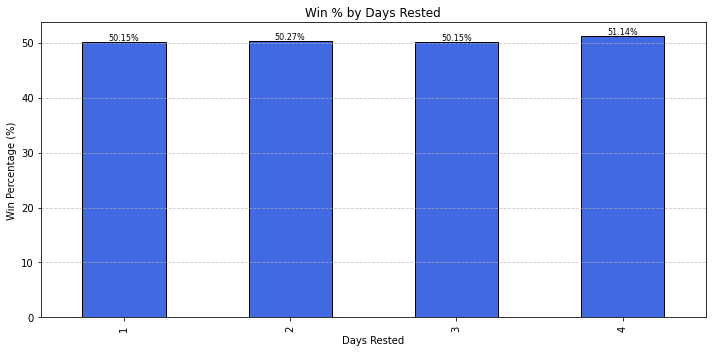

In [26]:
days_rested_winrate = full.groupby('days_rested')['won'].mean() * 100

ax = days_rested_winrate.plot(
    kind='bar', 
    color='royalblue', 
    edgecolor='black', 
    figsize=(10,5)
)

plt.title('Win % by Days Rested')
plt.ylabel('Win Percentage (%)')
plt.xlabel('Days Rested')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}%", 
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', 
        va='bottom', 
        fontsize=8
    )

plt.tight_layout()
plt.show()


In [27]:
removed_columns = list(full.columns[full.dtypes == "object"]) + removed_columns

In [28]:
selected_columns = full.columns[~full.columns.isin(removed_columns)]

In [29]:
full.head()

,mp,fg,fga,fg%,3p,3pa,3p%,ft,fta,ft%,...,season,date,won,target,home_next,team_opp_next_x,date_next,team_opp_next_y,team_y,days_rested
0,240.0,40.0,82.0,0.488,8.0,24.0,0.333,16.0,16.0,1.000,...,2017,2016-10-25,False,1,1.0,LAL,2016-10-28,UTA,LAL,3
1,240.0,40.0,85.0,0.471,7.0,33.0,0.212,13.0,18.0,0.722,...,2017,2016-10-25,False,1,0.0,NOP,2016-10-28,GSW,NOP,3
2,240.0,47.0,98.0,0.480,12.0,24.0,0.500,23.0,26.0,0.885,...,2017,2016-10-25,True,1,0.0,SAC,2016-10-27,SAS,SAC,2
3,240.0,45.0,94.0,0.479,13.0,35.0,0.371,14.0,19.0,0.737,...,2017,2016-10-25,True,1,0.0,TOR,2016-10-28,CLE,TOR,3
4,240.0,32.0,87.0,0.368,9.0,27.0,0.333,15.0,20.0,0.750,...,2017,2016-10-25,False,1,1.0,MEM,2016-10-29,NYK,MEM,4


Exploratory Data analysis does not modify the dataframe in any way. This chapter's goal is to simply point out any relationships, trends, and/or anomalies. 

In the next chapter "Feature engineering", we use the new found knowledge to create/remove certain features from the data to allow optimal training.